<a href="https://colab.research.google.com/github/24aps3004-debug/K-ANAND/blob/main/Chapter_01_Introduction_to_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [8]:
def NewtonRaphsonRootFinding(f, df, x0, TolX=1e-5, MaxIter=50):
    """
    Newton-Raphson root finding method.

    Parameters:
        f       : function f(x)
        df      : derivative function df(x)/dx (or numeric/None)
        x0      : initial guess
        TolX    : tolerance for consecutive step difference |x_k - x_{k-1}|
        MaxIter : maximum number of iterations

    Returns:
        x  : point reached by the algorithm
        fx : f(x) evaluated at the final point
        xx : list containing iteration history of x
    """
    h = 1e-4
    h2 = 2 * h
    TolFun = np.finfo(float).eps  # MATLAB 'eps' equivalent

    xx = [x0]
    fx = f(x0)

    k = 0
    for k in range(MaxIter):
        # Use derivative function if callable, otherwise numerical derivative
        if callable(df):
            dfdx = df(xx[k])
        else:
            dfdx = (f(xx[k] + h) - f(xx[k] - h)) / h2

        dx = -fx / dfdx
        xx.append(xx[k] + dx)
        fx = f(xx[-1])

        if abs(fx) < TolFun or abs(dx) < TolX:
            break

    x = xx[-1]
    if k == MaxIter - 1:
        print(f"The best in {MaxIter} iterations")

    return x, fx, xx

Newton-Raphson Root: 3.000000000015066
f(x) at Root: 3.012701199622825e-11
Built-in fzero equivalent result: 3.0


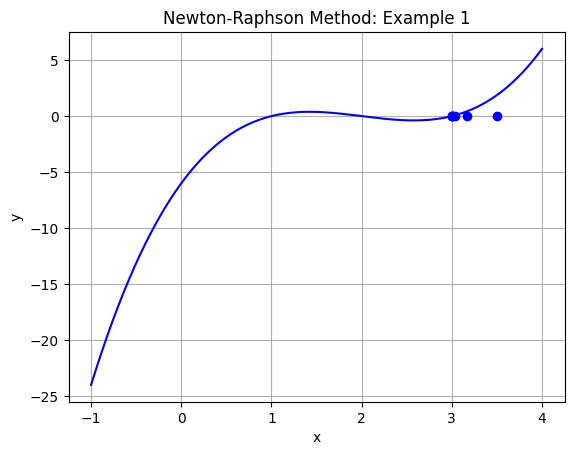

In [9]:
# Objective Function
def example_1(x):
    # y = x^3 - 3*x + 2
    return x**3 - 6 * x**2 + 11 * x - 6

# Derivative Function
def derexample_1(x):
    # y = 3*x^2 - 3
    return 3 * x**2 - 12 * x + 11

if __name__ == "__main__":
    # Input parameters
    x0 = 3.5         # Initial guess
    TolX = 1e-5      # Tolerance for convergence
    TolF = 1e-5      # Tolerance for function value
    MaxIter = 50     # Maximum number of iterations

    # Call Newton-Raphson solver
    x, fx, xx = NewtonRaphsonRootFinding(example_1, derexample_1, x0, TolX, MaxIter)
    print(f"Newton-Raphson Root: {x}")
    print(f"f(x) at Root: {fx}")

    # Built-in routine equivalent to MATLAB's fzero('example_1', [-1, 4])
    sol = root_scalar(example_1, bracket=[-1, 4], method='brentq')
    print(f"Built-in fzero equivalent result: {sol.root}")

    # Plotting routine
    x_grid = np.arange(-1, 4.01, 0.01)
    y_grid = example_1(x_grid)

    plt.figure()
    plt.plot(x_grid, y_grid, 'b')
    plt.grid(True)
    plt.plot(xx, np.zeros(len(xx)), 'bo')  # Iteration markers
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Newton-Raphson Method: Example 1')
    plt.show()

Newton-Raphson Root: 2.0287578380891675
f(x) at Root: 1.300635155132568e-10
Built-in fzero equivalent result: 2.028757838110434


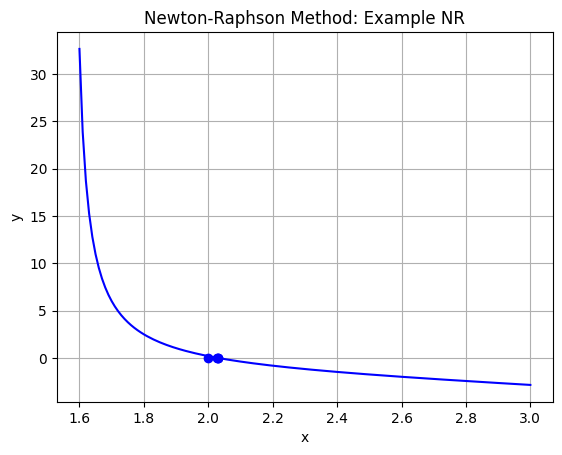

In [10]:
# Objective Function
def example_NR(x):
    # y = x^3 - 3*x + 2
    return np.tan(np.pi - x) - x

# Derivative Function
def derexample_NR(x):
    # y = 3*x^2 - 3
    return -(1 / np.cos(np.pi - x))**2 - 1

if __name__ == "__main__":
    # Input parameters
    x0 = 2.0         # Initial guess
    TolX = 1e-5      # Tolerance for convergence
    TolF = 1e-5      # Tolerance for function value
    MaxIter = 50     # Maximum number of iterations

    # Call Newton-Raphson solver
    x, fx, xx = NewtonRaphsonRootFinding(example_NR, derexample_NR, x0, TolX, MaxIter)
    print(f"Newton-Raphson Root: {x}")
    print(f"f(x) at Root: {fx}")

    # Built-in routine equivalent to MATLAB's fzero('example_NR', [1.6, 3])
    sol = root_scalar(example_NR, bracket=[1.6, 3], method='brentq')
    print(f"Built-in fzero equivalent result: {sol.root}")

    # Plotting routine
    x_grid = np.arange(1.6, 3.01, 0.01)
    y_grid = example_NR(x_grid)

    plt.figure()
    plt.plot(x_grid, y_grid, 'b')
    plt.grid(True)
    plt.plot(xx, np.zeros(len(xx)), 'bo')  # Iteration markers
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Newton-Raphson Method: Example NR')
    plt.show()